# Computing Determinants and Inverse Matrices

## 📚 Learning Objectives

By completing this notebook, you will:
- Compute determinants and inverse matrices computationally using Python/NumPy
- Understand the relationship between determinants and matrix invertibility
- Apply determinants and inverses to ML problems
- Handle singular and near-singular matrices

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 3, lesson 04 "Gradient Descent and Loss Functions" — the same closed-form least-squares answer: the inverse is what makes it computable, the determinant tells you when it is not.

**Used later in:** Course 04 (AIAT 114) — Unit 1, lesson 06 "Ridge and Lasso Regression" — ridge exists because correlated features make that inverse unstable.

---

This notebook covers practical activities from **Course 03, Unit 1**:
- Computing determinants and inverse matrices computationally

---

## Introduction

**Determinants** measure matrix invertibility, and **inverse matrices** are used in solving linear systems and optimization problems in machine learning.


---

## 📌 Real case: the regression that broke the software

In 1967 James W. Longley published *"An Appraisal of Least Squares Programs for the Electronic Computer
from the Point of View of the User"* (*Journal of the American Statistical Association* 62(319),
819–841). He had run one
ordinary regression — **16 observations, 6 predictors** of US employment — through the statistical packages
of the day, and they disagreed with each other. Some were wrong in the leading digit. The data was fine.
The *columns* were the problem: GNP, the GNP deflator, population and year all move together, so the
matrix XᵀX that the normal equations must invert was very nearly singular, and the arithmetic could not
survive dividing by something that close to zero. NIST now keeps Longley's data as a Statistical Reference
Dataset with certified answers and a stated difficulty of "higher" — it exists so you can find out whether
a regression routine is numerically honest.

**What goes wrong without this.** A determinant that is merely *small* rather than zero passes every
"is it invertible?" test, and then quietly multiplies your measurement noise by tens of thousands. Part 2
below builds exactly that matrix and prints the result: determinant −0.0002, inverse entries near 20,000.
Nobody gets an error message. You get numbers, and they are wrong.


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Setup: NumPy for the matrix computations, Matplotlib for any figures in this lesson.

import numpy as np
import matplotlib.pyplot as plt

# Confirm the environment is ready before any math starts.
print("✅ Libraries imported!")
print("\nComputing Determinants and Inverse Matrices")
print("=" * 60)


✅ Libraries imported!

Computing Determinants and Inverse Matrices


## Part 1: Computing Determinants


In [2]:
# Compute determinants by hand (2x2 and 3x3 cofactor formulas) and check them against NumPy.
# The determinant tells you whether a system has a unique solution — det = 0 means trouble ahead.

print("=" * 60)
print("Part 1: Computing Determinants")
print("=" * 60)

# Determinant of 2x2 matrix: det([[a,b],[c,d]]) = ad - bc
def determinant_2x2(matrix):
    """Compute determinant of 2x2 matrix"""
    return matrix[0, 0] * matrix[1, 1] - matrix[0, 1] * matrix[1, 0]

# Determinant of 3x3 matrix using cofactor expansion
def determinant_3x3(matrix):
    """Compute determinant of 3x3 matrix"""
    a, b, c = matrix[0]
    d, e, f = matrix[1]
    g, h, i = matrix[2]
    return a*(e*i - f*h) - b*(d*i - f*g) + c*(d*h - e*g)

# Example matrices
A_2x2 = np.array([[2, 1],
                  [1, -1]])
A_3x3 = np.array([[2, 1, -1],
                  [-3, -1, 2],
                  [-2, 1, 2]])

# Evaluate both implementations on the same matrices to confirm they agree.
print("\n2x2 Matrix:")
print(A_2x2)
det_2x2_manual = determinant_2x2(A_2x2)
det_2x2_numpy = np.linalg.det(A_2x2)
print(f"Determinant (manual): {det_2x2_manual:.2f}")
print(f"Determinant (NumPy): {det_2x2_numpy:.2f}")

print("\n3x3 Matrix:")
print(A_3x3)
det_3x3_manual = determinant_3x3(A_3x3)
det_3x3_numpy = np.linalg.det(A_3x3)
print(f"Determinant (manual): {det_3x3_manual:.2f}")
print(f"Determinant (NumPy): {det_3x3_numpy:.2f}")

# Properties of determinants
print("\n" + "-" * 60)
print("Properties of Determinants:")
print("-" * 60)
print("1. det(A^T) = det(A)")
print(f"   det(A) = {np.linalg.det(A_2x2):.2f}, det(A^T) = {np.linalg.det(A_2x2.T):.2f}")

print("\n2. det(AB) = det(A) * det(B)")
B_2x2 = np.array([[1, 2], [3, 4]])
print(f"   det(A) * det(B) = {np.linalg.det(A_2x2) * np.linalg.det(B_2x2):.2f}")
print(f"   det(AB) = {np.linalg.det(A_2x2 @ B_2x2):.2f}")

print("\n3. If det(A) = 0, A is singular (not invertible)")
singular = np.array([[1, 2], [2, 4]])  # Second row is 2x first row
print(f"   Singular matrix det = {np.linalg.det(singular):.2f}")

print("\n✅ Determinant computation implemented!")


Part 1: Computing Determinants

2x2 Matrix:
[[ 2  1]
 [ 1 -1]]
Determinant (manual): -3.00
Determinant (NumPy): -3.00

3x3 Matrix:
[[ 2  1 -1]
 [-3 -1  2]
 [-2  1  2]]
Determinant (manual): -1.00
Determinant (NumPy): -1.00

------------------------------------------------------------
Properties of Determinants:
------------------------------------------------------------
1. det(A^T) = det(A)
   det(A) = -3.00, det(A^T) = -3.00

2. det(AB) = det(A) * det(B)
   det(A) * det(B) = 6.00
   det(AB) = 6.00

3. If det(A) = 0, A is singular (not invertible)
   Singular matrix det = 0.00

✅ Determinant computation implemented!


## Part 2: Computing Inverse Matrices


In [3]:
# Invert a 2x2 matrix with the textbook adjugate formula, then let NumPy handle the general case.
# The inverse 'undoes' a matrix — the matrix analogue of dividing — and exists only when det != 0.

print("\n" + "=" * 60)
print("Part 2: Computing Inverse Matrices")
print("=" * 60)

# For 2x2: A^(-1) = (1/det(A)) * [[d, -b], [-c, a]] where A = [[a, b], [c, d]]
def inverse_2x2(matrix):
    """Compute inverse of 2x2 matrix"""
    det = determinant_2x2(matrix)
    if abs(det) < 1e-10:
        raise ValueError("Matrix is singular (determinant is 0)")
    
    a, b = matrix[0]
    c, d = matrix[1]
    inv = (1/det) * np.array([[d, -b], [-c, a]])
    return inv

# Example
A = np.array([[2, 1],
              [1, -1]])

print(f"Matrix A:\n{A}")
print(f"\nDeterminant: {np.linalg.det(A):.2f}")

# Manual computation
A_inv_manual = inverse_2x2(A)
print(f"\nInverse (manual):\n{A_inv_manual}")

# NumPy computation
A_inv_numpy = np.linalg.inv(A)
print(f"\nInverse (NumPy):\n{A_inv_numpy}")

# Verify: A * A^(-1) = I
I_check = A @ A_inv_numpy
print(f"\nVerification (A * A^(-1) should be identity):\n{I_check}")
print(f"\nIdentity matrix:\n{np.eye(2)}")

# Using NumPy's pinv for near-singular matrices
print("\n" + "-" * 60)
print("Handling Near-Singular Matrices:")
print("-" * 60)
nearly_singular = np.array([[1, 2.0001],
                            [2, 4]])
print(f"Nearly singular matrix:\n{nearly_singular}")
print(f"Determinant: {np.linalg.det(nearly_singular):.6f}")

try:
    inv_regular = np.linalg.inv(nearly_singular)
    print(f"Inverse (regular):\n{inv_regular}")
except np.linalg.LinAlgError:
    print("Regular inverse fails (singular matrix)")

# Use pseudo-inverse for stability
inv_pseudo = np.linalg.pinv(nearly_singular)
print(f"Pseudo-inverse (stable):\n{inv_pseudo}")

print("\n✅ Inverse matrix computation implemented!")



Part 2: Computing Inverse Matrices
Matrix A:
[[ 2  1]
 [ 1 -1]]

Determinant: -3.00

Inverse (manual):
[[ 0.33333333  0.33333333]
 [ 0.33333333 -0.66666667]]

Inverse (NumPy):
[[ 0.33333333  0.33333333]
 [ 0.33333333 -0.66666667]]

Verification (A * A^(-1) should be identity):
[[1.00000000e+00 0.00000000e+00]
 [5.55111512e-17 1.00000000e+00]]

Identity matrix:
[[1. 0.]
 [0. 1.]]

------------------------------------------------------------
Handling Near-Singular Matrices:
------------------------------------------------------------
Nearly singular matrix:
[[1.     2.0001]
 [2.     4.    ]]
Determinant: -0.000200
Inverse (regular):
[[-19999.99999996  10000.49999998]
 [  9999.99999998  -4999.99999999]]
Pseudo-inverse (stable):
[[-20000.00000014  10000.50000007]
 [ 10000.00000007  -5000.00000003]]

✅ Inverse matrix computation implemented!


## Part 3: Application to ML Problems


In [4]:
# ML payoff: solve linear regression with the normal equations via an explicit matrix inverse,
# then compare with np.linalg.solve — same answer, but solve() is the numerically safer habit.

print("\n" + "=" * 60)
print("Part 3: Application to ML Problems")
print("=" * 60)

# Example: Linear regression using normal equations
# w = (X^T * X)^(-1) * X^T * y
print("\nLinear Regression Using Matrix Inversion:")
print("-" * 60)

# Sample data
X_data = np.array([1, 2, 3, 4, 5])
y_data = np.array([2, 4, 5, 4, 5])

# Design matrix
X = np.vstack([np.ones(len(X_data)), X_data]).T

# Normal equations: (X^T * X) * w = X^T * y
# w = (X^T * X)^(-1) * X^T * y
XTX = X.T @ X
XTy = X.T @ y_data

print(f"X^T * X:\n{XTX}")
print(f"\nDeterminant of (X^T * X): {np.linalg.det(XTX):.2f}")

# Check if invertible
if np.linalg.det(XTX) > 1e-10:
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv @ XTy
    print(f"\nInverse of (X^T * X):\n{XTX_inv}")
    print(f"\nWeights: w0 = {w[0]:.2f}, w1 = {w[1]:.2f}")
    print(f"Model: y = {w[0]:.2f} + {w[1]:.2f}*x")
else:
    print("Matrix is singular, use pseudo-inverse")
    XTX_inv = np.linalg.pinv(XTX)
    w = XTX_inv @ XTy
    print(f"Weights: w0 = {w[0]:.2f}, w1 = {w[1]:.2f}")

# Compare with direct solve (more stable)
w_solve = np.linalg.solve(XTX, XTy)
print(f"\nUsing np.linalg.solve (more stable):")
print(f"Weights: w0 = {w_solve[0]:.2f}, w1 = {w_solve[1]:.2f}")

print("\n✅ ML application: Linear regression using matrix inversion!")



Part 3: Application to ML Problems

Linear Regression Using Matrix Inversion:
------------------------------------------------------------
X^T * X:
[[ 5. 15.]
 [15. 55.]]

Determinant of (X^T * X): 50.00

Inverse of (X^T * X):
[[ 1.1 -0.3]
 [-0.3  0.1]]

Weights: w0 = 2.20, w1 = 0.60
Model: y = 2.20 + 0.60*x

Using np.linalg.solve (more stable):
Weights: w0 = 2.20, w1 = 0.60

✅ ML application: Linear regression using matrix inversion!


## Part 4: Seeing the difference between "invertible" and "trustworthy"

Part 2 printed a matrix whose determinant is −0.0002 — **not zero**, so every textbook invertibility
test says "go ahead" — and whose inverse contains entries near 20,000. Numbers alone make that look
like a curiosity. The picture makes it look like what it is.

Two equations in two unknowns are two lines; the solution is where they cross. Below, the first
equation is held fixed and the second is tilted towards it, frame by frame, so the lines close like
a pair of scissors. **Every system in the row has exactly the same solution, x = (1, 1)**, and every
one of them receives exactly the same tiny nudge on its right-hand side. Watch what the crossing
point does.

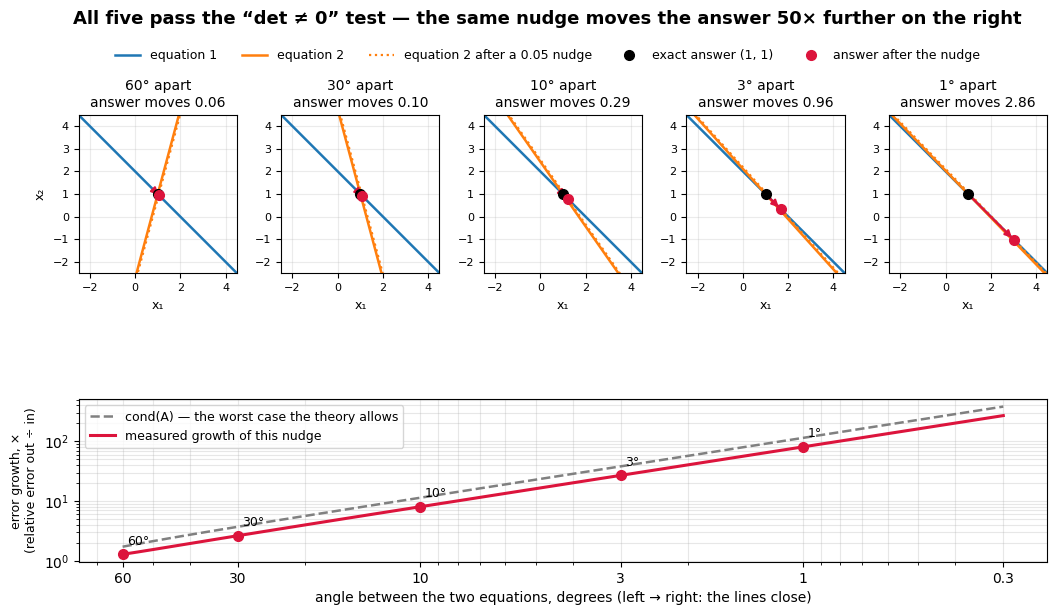

frame |      angle |     det(A) |  cond(A) | answer moved | error growth
------------------------------------------------------------------------------
    1 |        60° |   -0.86603 |      1.7 |        0.058 |         1.3×
    2 |        30° |   -0.50000 |      3.7 |        0.100 |         2.6×
    3 |        10° |   -0.17365 |     11.4 |        0.288 |         8.1×
    4 |         3° |   -0.05234 |     38.2 |        0.955 |        27.0×
    5 |         1° |   -0.01745 |    114.6 |        2.865 |        81.0×
------------------------------------------------------------------------------
 ctrl | 60° × 0.01 | -0.0000866 |      1.7 |        0.058 |         1.3×

Read the control row against frame 5: its determinant is 0.0000866, which is
202x SMALLER than the determinant of the worst frame in the figure -
yet it is the best-behaved system on the page. The determinant answers 'is it exactly
singular?'. The condition number answers the question you actually have: 'if my numbers
are slight

In [5]:
# Frame-grid storyboard: watch a healthy linear system turn untrustworthy, one frame at a time.
# WHY: "det != 0 therefore invertible" is a yes/no test, but usability is a matter of degree. The
#      degree is visible: as two equations become near-duplicates of each other, the point where
#      they cross stops being pinned down, and a nudge you cannot see moves the answer a long way.
# HOW: both equations are written with UNIT-LENGTH coefficient rows, so nothing below is an artefact
#      of scaling. Equation 1 is fixed; equation 2 is tilted towards it. The right-hand side of every
#      system is built from the same x = (1, 1), so the exact answer never changes between frames.

import numpy as np
import matplotlib.pyplot as plt

x_true = np.array([1.0, 1.0])   # the answer every frame is supposed to return
delta = 0.05                    # the nudge applied to equation 2's right-hand side, same in every frame
angles_deg = [60, 30, 10, 3, 1]  # the storyboard: how far apart the two equations are


def system_for(angle_deg):
    """Two equations whose coefficient rows are unit vectors `angle_deg` apart."""
    a1 = np.deg2rad(45.0)                       # direction of equation 1's coefficients (held fixed)
    a2 = a1 - np.deg2rad(angle_deg)             # equation 2, tilted towards equation 1
    A = np.array([[np.cos(a1), np.sin(a1)],
                  [np.cos(a2), np.sin(a2)]])
    return A, A @ x_true                        # b built from x_true => the exact answer is always (1, 1)


def line_y(A, b, row, xs):
    """The set of points satisfying one equation, as a line y(x)."""
    return (b[row] - A[row, 0] * xs) / A[row, 1]


def moved(angle_deg):
    """Re-solve the same system after the nudge; return how far the answer travelled."""
    A, b = system_for(angle_deg)
    x_p = np.linalg.solve(A, b + np.array([0.0, delta]))
    return np.linalg.norm(x_p - x_true)


fig = plt.figure(figsize=(12.5, 6.2))
gs = fig.add_gridspec(2, len(angles_deg), height_ratios=[1.35, 1.0], hspace=0.5, wspace=0.28)
xs = np.linspace(-2.5, 4.5, 50)
handles = None

for c, ang in enumerate(angles_deg):
    A, b = system_for(ang)
    b_p = b + np.array([0.0, delta])            # the same small nudge in every frame
    x_p = np.linalg.solve(A, b_p)
    ax = fig.add_subplot(gs[0, c])
    h1, = ax.plot(xs, line_y(A, b, 0, xs), color="tab:blue", lw=1.8)
    h2, = ax.plot(xs, line_y(A, b, 1, xs), color="tab:orange", lw=1.8)
    h3, = ax.plot(xs, line_y(A, b_p, 1, xs), color="tab:orange", lw=1.6, ls=":")
    h4, = ax.plot(*x_true, "ko", ms=7, zorder=5)
    h5, = ax.plot(*x_p, "o", color="crimson", ms=7, zorder=5)
    ax.annotate("", xy=x_p, xytext=x_true, arrowprops=dict(arrowstyle="-|>", color="crimson", lw=1.6))
    ax.set_xlim(-2.5, 4.5); ax.set_ylim(-2.5, 4.5); ax.set_aspect("equal")
    ax.set_title(f"{ang}\u00b0 apart\nanswer moves {np.linalg.norm(x_p - x_true):.2f}", fontsize=10)
    ax.set_xlabel("x\u2081", fontsize=9)
    if c == 0:
        ax.set_ylabel("x\u2082", fontsize=9)
        handles = [h1, h2, h3, h4, h5]
    ax.grid(alpha=0.25); ax.tick_params(labelsize=8)

fig.legend(handles,
           ["equation 1", "equation 2", f"equation 2 after a {delta} nudge",
            "exact answer (1, 1)", "answer after the nudge"],
           loc="upper center", bbox_to_anchor=(0.5, 0.955), ncol=5, fontsize=9, frameon=False)

# Bottom panel: the same experiment run at 60 angles, so the trend between the frames is visible too.
# Plotted as error GROWTH (relative error out / relative error in) because that is the quantity the
# condition number claims to bound - so the two curves can honestly share one axis.
sweep = np.logspace(np.log10(60), np.log10(0.3), 60)
amp, cond = [], []
for ang in sweep:
    A, b = system_for(ang)
    x_p = np.linalg.solve(A, b + np.array([0.0, delta]))
    amp.append((np.linalg.norm(x_p - x_true) / np.linalg.norm(x_true)) / (delta / np.linalg.norm(b)))
    cond.append(np.linalg.cond(A))

axb = fig.add_subplot(gs[1, :])
axb.plot(sweep, cond, color="grey", lw=1.8, ls="--", label="cond(A) \u2014 the worst case the theory allows")
axb.plot(sweep, amp, color="crimson", lw=2.2, label="measured growth of this nudge")
for ang in angles_deg:                          # mark the five storyboard frames on the curve
    A, b = system_for(ang)
    x_p = np.linalg.solve(A, b + np.array([0.0, delta]))
    a = (np.linalg.norm(x_p - x_true) / np.linalg.norm(x_true)) / (delta / np.linalg.norm(b))
    axb.plot(ang, a, "o", color="crimson", ms=7)
    axb.annotate(f"{ang}\u00b0", (ang, a), textcoords="offset points", xytext=(3, 7), fontsize=9)
axb.set_xscale("log"); axb.set_yscale("log"); axb.invert_xaxis()
axb.set_xticks([60, 30, 10, 3, 1, 0.3]); axb.set_xticklabels(["60", "30", "10", "3", "1", "0.3"])
axb.set_xlabel("angle between the two equations, degrees (left \u2192 right: the lines close)")
axb.set_ylabel("error growth, \u00d7\n(relative error out \u00f7 in)", fontsize=9)
axb.grid(alpha=0.3, which="both"); axb.legend(loc="upper left", fontsize=9)

ratio = moved(angles_deg[-1]) / moved(angles_deg[0])
fig.suptitle(f"All five pass the \u201cdet \u2260 0\u201d test \u2014 the same nudge moves the answer "
             f"{ratio:.0f}\u00d7 further on the right", fontsize=13, fontweight="bold", y=1.0)
plt.show()

# The step table behind the storyboard: one row per frame.
print(f"{'frame':>5} | {'angle':>10} | {'det(A)':>10} | {'cond(A)':>8} | {'answer moved':>12} | {'error growth':>12}")
print("-" * 78)
for i, ang in enumerate(angles_deg, start=1):
    A, b = system_for(ang)
    x_p = np.linalg.solve(A, b + np.array([0.0, delta]))
    d = np.linalg.norm(x_p - x_true)
    growth = (d / np.linalg.norm(x_true)) / (delta / np.linalg.norm(b))
    print(f"{i:5d} | {ang:9.0f}\u00b0 | {np.linalg.det(A):10.5f} | {np.linalg.cond(A):8.1f} | {d:12.3f} | {growth:11.1f}\u00d7")

# The control that kills the determinant test outright: take the HEALTHY 60-degree system and
# multiply both equations (and the nudge, to keep the comparison fair) by 0.01. Nothing about the
# problem changed - the lines are in the same place - but the determinant falls through the floor.
A0, b0 = system_for(60)
s = 0.01
A_s, b_s, delta_s = s * A0, s * b0, s * delta
x_s = np.linalg.solve(A_s, b_s + np.array([0.0, delta_s]))
print("-" * 78)
print(f"{'ctrl':>5} | {'60\u00b0 \u00d7 0.01':>10} | {np.linalg.det(A_s):10.7f} | {np.linalg.cond(A_s):8.1f} | "
      f"{np.linalg.norm(x_s - x_true):12.3f} | "
      f"{(np.linalg.norm(x_s - x_true) / np.linalg.norm(x_true)) / (delta_s / np.linalg.norm(b_s)):11.1f}\u00d7")
print()
print(f"Read the control row against frame 5: its determinant is {abs(np.linalg.det(A_s)):.7f}, which is")
print(f"{abs(np.linalg.det(system_for(1)[0])) / abs(np.linalg.det(A_s)):.0f}x SMALLER than the determinant of the worst frame in the figure -")
print("yet it is the best-behaved system on the page. The determinant answers 'is it exactly")
print("singular?'. The condition number answers the question you actually have: 'if my numbers")
print("are slightly off, how far off is the answer?'")


**What to look for in the figure above.** Read the top row left to right. The blue line never moves
and the black dot — the exact answer (1, 1) — never moves either. What changes is the **angle** at which
the orange line crosses it: 60°, then 30°, 10°, 3°, 1°. The dotted orange line is that same equation
after the nudge, and in every frame it lies almost on top of the solid one — the *input* barely
changed, in all five frames equally. Now follow the red arrow. In the first frame it is too short to
see; by the last frame the answer has walked from (1, 1) to roughly (3, −1). The bottom panel runs the
same experiment at 60 angles: the red curve is the growth actually measured, and the grey dashed curve
is `cond(A)`, the worst case the theory permits — the red curve stays under it everywhere, as it must.

The step table underneath gives the exact numbers, and its last row is the one to argue about in class:
the well-behaved 60° system, with both equations multiplied by 0.01, has a determinant **two hundred
times smaller** than the near-useless 1° system — and behaves exactly as well as it did before, growing
the same nudge by 1.3× instead of 81×. A determinant near zero is neither
necessary nor sufficient for trouble. `np.linalg.cond` is the number to print.

---

## ⚠️ Where this breaks

- **"det ≠ 0" is not the same as "safe to invert."** The near-singular example in Part 2 has determinant
  −0.000200 — not zero, so the textbook test passes — and its inverse has entries around 20,000. Multiply a
  measurement error of 0.001 by 20,000 and your "solution" has moved by 20. The quantity that actually
  answers the question is the **condition number** (`np.linalg.cond`), which reports how much a small change
  in the input is amplified in the output.
- **The determinant is scale-sensitive, so it is the wrong test anyway.** Take a perfectly well-behaved
  100×100 matrix and multiply it by 0.1: its determinant becomes 10⁻¹⁰⁰, vanishingly small, while the matrix
  is exactly as invertible as before. Determinants scale with the size of the numbers; condition numbers
  do not.
- **Cheaper and safer alternative.** You almost never need A⁻¹ itself. `np.linalg.solve(A, b)` gets the
  answer without forming it. `np.linalg.pinv` and `lstsq` handle the singular case by discarding the
  directions the data does not determine — which is what Part 2's pseudo-inverse is doing. Statistically,
  the same repair is ridge regression (Course 04, Unit 1, lesson 06): add a small constant to the diagonal
  and the matrix stops being nearly singular.


---

## 💬 Discuss

1. Longley's data was real and correct; only the arithmetic failed. Where does responsibility for a result
   like that sit — with the economist, the software vendor, or the person who read the printout? What would
   you personally require before trusting a published coefficient today?
2. The near-singular example produces an inverse with entries around 20,000 from a matrix whose entries are
   between 1 and 4, and the notebook's own check `A @ A_inv` still comes back as the identity. Explain
   precisely why that check does not settle the question of whether the answer is usable.
3. Ridge regression fixes ill-conditioning by adding a constant to the diagonal — deliberately solving a
   *different* problem from the one you were asked. When is that an acceptable trade, and what exactly do
   you owe a client in your description of the coefficients you hand them?


## Summary

### Key Concepts:
1. **Determinant**: Scalar value indicating matrix invertibility
   - det(A) = 0 → matrix is singular (not invertible)
   - det(A) ≠ 0 → matrix is invertible

2. **Inverse Matrix**: A^(-1) such that A * A^(-1) = I
   - Used for solving linear systems
   - Computationally expensive (use solve() instead when possible)

3. **Pseudo-Inverse**: Used for singular or near-singular matrices
   - More numerically stable
   - Useful in ML for regularization

### Best Practices:
- Use `np.linalg.solve()` instead of computing inverse explicitly
- Check determinant before inversion (avoid singular matrices)
- Use pseudo-inverse (`pinv`) for near-singular matrices
- Verify A * A^(-1) = I after computation

### Applications:
- Linear regression (normal equations)
- Solving linear systems
- Optimization problems
- Neural network weight updates

**Reference:** Course 03, Unit 1: "Linear Algebra for Machine Learning" - Determinants and inverses practical content


## 📚 References

1. Deisenroth, M. P., Faisal, A. A., & Ong, C. S. (2020). *Mathematics for Machine Learning*, Ch. 4: Matrix Decompositions. Cambridge University Press. <https://mml-book.github.io/>
2. Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*, Ch. 2: Linear Algebra. MIT Press. <https://www.deeplearningbook.org/>
3. Vyas, N., Morwani, D., Zhao, R., Kwun, M., Shapira, I., Brandfonbrener, D., Janson, L., & Kakade, S. (2024). *SOAP: Improving and Stabilizing Shampoo using Adam*. arXiv. <https://arxiv.org/abs/2409.11321> — where matrix inverses and eigenbases show up inside a modern optimizer, and why they are approximated rather than formed.
4. Dereziński, M., & Mahoney, M. W. (2024). *Recent and Upcoming Developments in Randomized Numerical Linear Algebra for Machine Learning*. arXiv. <https://arxiv.org/abs/2406.11151> — conditioning, sketching and the numerical realities when the matrix is too large to invert.
